In [50]:
import pandas as pd

In [51]:
# Load the dataset
df = pd.read_csv("student_dropout_dataset.csv")

In [52]:
# Show first 5 rows
print(df.head())

  student_id  age      region enroll_date  exam_season  courses_enrolled  \
0   STU00001   26  Alexandria  2024-01-13            0                 3   
1   STU00002   23       Amman  2024-05-05            0                 6   
2   STU00003   17       Dubai  2024-03-12            0                 3   
3   STU00004   23  Alexandria  2024-12-12            0                 6   
4   STU00005   20     Baghdad  2024-02-14            0                 5   

   completed_assignments  completion_rate  login_frequency  \
0                      5           0.3571             5.29   
1                      0           0.0000             0.84   
2                      1           0.0435             1.79   
3                     13           0.4396             0.78   
4                      5           0.2078             0.92   

   last_activity_days_ago  forum_posts_count  dropout_score  label  \
0                      10                  5         0.1064      0   
1                       7     

In [53]:
# General info: datatypes, missing values
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   student_id              5000 non-null   object 
 1   age                     5000 non-null   int64  
 2   region                  5000 non-null   object 
 3   enroll_date             5000 non-null   object 
 4   exam_season             5000 non-null   int64  
 5   courses_enrolled        5000 non-null   int64  
 6   completed_assignments   5000 non-null   int64  
 7   completion_rate         5000 non-null   float64
 8   login_frequency         5000 non-null   float64
 9   last_activity_days_ago  5000 non-null   int64  
 10  forum_posts_count       5000 non-null   int64  
 11  dropout_score           5000 non-null   float64
 12  label                   5000 non-null   int64  
 13  label_multiclass        5000 non-null   int64  
 14  label_name              5000 non-null   

In [54]:
# Summary statistics for numeric columns
print(df.describe())

               age  exam_season  courses_enrolled  completed_assignments  \
count  5000.000000  5000.000000       5000.000000            5000.000000   
mean     23.736600     0.094000          3.999400               5.188400   
std       4.583211     0.291858          1.997348               6.109466   
min      17.000000     0.000000          1.000000               0.000000   
25%      20.000000     0.000000          2.000000               1.000000   
50%      24.000000     0.000000          4.000000               3.000000   
75%      27.000000     0.000000          6.000000               7.000000   
max      40.000000     1.000000          7.000000              35.000000   

       completion_rate  login_frequency  last_activity_days_ago  \
count      5000.000000      5000.000000               5000.0000   
mean          0.260985         3.453820                  9.3564   
std           0.249010         3.248316                  9.4361   
min           0.000000         0.100000        

In [55]:
# Check target distribution
print("Binary label distribution:")
print(df['label'].value_counts())

print("\nMulticlass label distribution:")
print(df['label_multiclass'].value_counts())

Binary label distribution:
label
1    3296
0    1704
Name: count, dtype: int64

Multiclass label distribution:
label_multiclass
0    1704
1    1663
2    1633
Name: count, dtype: int64


In [56]:
from sklearn.preprocessing import StandardScaler

In [57]:
# Encode 'region' with one-hot encoding
df = pd.get_dummies(df, columns=['region'], drop_first=True)

In [58]:
# Convert 'enroll_date' to datetime and extract month
df['enroll_date'] = pd.to_datetime(df['enroll_date'])
df['enroll_month'] = df['enroll_date'].dt.month

In [59]:
# Drop 'student_id' and raw 'enroll_date' (not needed for ML)
df = df.drop(['student_id', 'enroll_date'], axis=1)

In [60]:
# Scale numeric features (optional but helpful for distance-based models)
numeric_cols = ['age', 'login_frequency', 'completed_assignments', 
                'completion_rate', 'last_activity_days_ago', 'courses_enrolled']
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

In [61]:
# Check the preprocessed dataframe
print(df.head())

        age  exam_season  courses_enrolled  completed_assignments  \
0  0.493895            0         -0.500414              -0.030840   
1 -0.160733            0          1.001729              -0.849325   
2 -1.469990            0         -0.500414              -0.685628   
3 -0.160733            0          1.001729               1.278734   
4 -0.815362            0          0.501014              -0.030840   

   completion_rate  login_frequency  last_activity_days_ago  \
0         0.386026         0.565328                0.068213   
1        -1.048195        -0.804750               -0.249747   
2        -0.873486        -0.512261                2.823864   
3         0.717370        -0.823223               -0.037774   
4        -0.213608        -0.780119                0.174200   

   forum_posts_count  dropout_score  label  ...  region_Amman region_Baghdad  \
0                  5         0.1064      0  ...         False          False   
1                  0         0.6627      1  ..

In [62]:
import numpy as np

In [63]:
# Engagement score = login_frequency * completion_rate
df['engagement_score'] = df['login_frequency'] * df['completion_rate']

In [64]:
# Recency feature is already in last_activity_days_ago (higher = less engaged)
df['recency'] = df['last_activity_days_ago']

In [65]:
# Low engagement flag: login < 2 and completion_rate < 0.3
df['low_engagement_flag'] = np.where((df['login_frequency'] < (2 - df['login_frequency'].mean())) &
                                     (df['completion_rate'] < (0.3 - df['completion_rate'].mean())), 1, 0)

In [66]:
# Optional: bin courses enrolled into light, medium, heavy load
df['course_load'] = pd.cut(df['courses_enrolled'], bins=[0, 2, 5, 7], labels=['light','medium','heavy'])

In [67]:
# One-hot encode the course_load
df = pd.get_dummies(df, columns=['course_load'], drop_first=True)

In [68]:
# Check the dataframe after feature engineering
print(df.head())

        age  exam_season  courses_enrolled  completed_assignments  \
0  0.493895            0         -0.500414              -0.030840   
1 -0.160733            0          1.001729              -0.849325   
2 -1.469990            0         -0.500414              -0.685628   
3 -0.160733            0          1.001729               1.278734   
4 -0.815362            0          0.501014              -0.030840   

   completion_rate  login_frequency  last_activity_days_ago  \
0         0.386026         0.565328                0.068213   
1        -1.048195        -0.804750               -0.249747   
2        -0.873486        -0.512261                2.823864   
3         0.717370        -0.823223               -0.037774   
4        -0.213608        -0.780119                0.174200   

   forum_posts_count  dropout_score  label  ...  region_Doha region_Dubai  \
0                  5         0.1064      0  ...        False        False   
1                  0         0.6627      1  ...     

In [69]:
from sklearn.model_selection import train_test_split

In [70]:
# Features (drop target columns)
X = df.drop(['label', 'label_multiclass'], axis=1)

In [71]:
# Targets
y_binary = df['label']                # For binary classification
y_multi = df['label_multiclass']      # For multiclass classification

In [72]:
# Binary classification train/test split
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X, y_binary, test_size=0.2, stratify=y_binary, random_state=42
)

In [73]:
# Multiclass classification train/test split
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X, y_multi, test_size=0.2, stratify=y_multi, random_state=42
)

In [74]:
# Check sizes
print("Binary Classification Split:")
print(X_train_bin.shape, X_test_bin.shape)
print("Multiclass Classification Split:")
print(X_train_multi.shape, X_test_multi.shape)

Binary Classification Split:
(4000, 25) (1000, 25)
Multiclass Classification Split:
(4000, 25) (1000, 25)


In [75]:
from sklearn.ensemble import RandomForestClassifier

In [77]:
# Check which columns are still non-numeric
print(df.dtypes[df.dtypes == 'object'])

label_name    object
dtype: object


In [78]:
# Identify remaining object columns
cat_cols = df.select_dtypes(include=['object']).columns
print("Categorical columns to encode:", cat_cols)

Categorical columns to encode: Index(['label_name'], dtype='object')


In [79]:
# Apply one-hot encoding
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [80]:
# Features and targets
X = df.drop(['label', 'label_multiclass'], axis=1)
y_binary = df['label']
y_multi = df['label_multiclass']

In [82]:
# Train/test split
from sklearn.model_selection import train_test_split

X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X, y_binary, test_size=0.2, stratify=y_binary, random_state=42
)

X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X, y_multi, test_size=0.2, stratify=y_multi, random_state=42
)

In [84]:
# Binary Classification Model
rf_binary = RandomForestClassifier(random_state=42)
rf_binary.fit(X_train_bin, y_train_bin)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [85]:
# Multiclass Classification Model
rf_multi = RandomForestClassifier(random_state=42)
rf_multi.fit(X_train_multi, y_train_multi)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [86]:
# Check feature importance for binary model
importances = rf_binary.feature_importances_
features = X.columns
importance_df = pd.DataFrame({'feature': features, 'importance': importances}).sort_values(by='importance', ascending=False)
print("Top Features for Binary Classification:")
print(importance_df.head(10))

Top Features for Binary Classification:
                  feature  importance
8           dropout_score    0.406561
5         login_frequency    0.129294
4         completion_rate    0.113788
21    low_engagement_flag    0.102313
24     label_name_at-risk    0.092972
7       forum_posts_count    0.061124
19       engagement_score    0.034929
25     label_name_dropped    0.027124
3   completed_assignments    0.018643
20                recency    0.004412


In [87]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [88]:
# Binary Classification Evaluation
y_pred_bin = rf_binary.predict(X_test_bin)

print("Binary Classification Metrics:\n")
print("Accuracy:", accuracy_score(y_test_bin, y_pred_bin))
print("\nClassification Report:\n", classification_report(y_test_bin, y_pred_bin))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_bin, y_pred_bin))


Binary Classification Metrics:

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       341
           1       1.00      1.00      1.00       659

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000


Confusion Matrix:
 [[341   0]
 [  0 659]]


In [89]:
# Multiclass Classification Evaluation
y_pred_multi = rf_multi.predict(X_test_multi)

print("\nMulticlass Classification Metrics:\n")
print("Accuracy:", accuracy_score(y_test_multi, y_pred_multi))
print("\nClassification Report:\n", classification_report(y_test_multi, y_pred_multi))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_multi, y_pred_multi))


Multiclass Classification Metrics:

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       341
           1       1.00      1.00      1.00       333
           2       1.00      1.00      1.00       326

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000


Confusion Matrix:
 [[341   0   0]
 [  0 333   0]
 [  0   0 326]]


In [94]:
import matplotlib.pyplot as plt

In [95]:
# Binary classification feature importance
importances = rf_binary.feature_importances_
features = X_train_bin.columns

In [96]:
importance_df = pd.DataFrame({'feature': features, 'importance': importances})
importance_df = importance_df.sort_values(by='importance', ascending=False)

In [97]:
# Show top 10 important features
print("Top 10 Features for Binary Classification:")
print(importance_df.head(10))

Top 10 Features for Binary Classification:
                  feature  importance
8           dropout_score    0.406561
5         login_frequency    0.129294
4         completion_rate    0.113788
21    low_engagement_flag    0.102313
24     label_name_at-risk    0.092972
7       forum_posts_count    0.061124
19       engagement_score    0.034929
25     label_name_dropped    0.027124
3   completed_assignments    0.018643
20                recency    0.004412


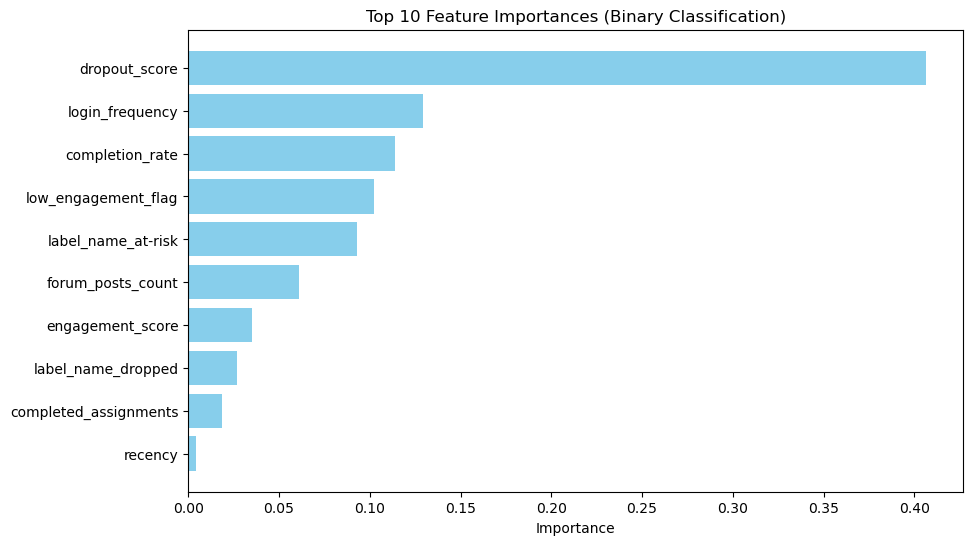

In [98]:
# Plot feature importance
plt.figure(figsize=(10,6))
plt.barh(importance_df['feature'].head(10)[::-1], importance_df['importance'].head(10)[::-1], color='skyblue')
plt.xlabel("Importance")
plt.title("Top 10 Feature Importances (Binary Classification)")
plt.show()

In [99]:
import joblib

In [100]:
# Save the models
joblib.dump(rf_binary, "rf_binary_dropout_model.pkl")
joblib.dump(rf_multi, "rf_multiclass_dropout_model.pkl")


['rf_multiclass_dropout_model.pkl']

In [101]:
# Save the scaler (important for new data)
joblib.dump(scaler, "scaler.pkl")

print("Models and scaler saved successfully!")


Models and scaler saved successfully!


In [102]:
# Load models for prediction
rf_binary_loaded = joblib.load("rf_binary_dropout_model.pkl")
rf_multi_loaded = joblib.load("rf_multiclass_dropout_model.pkl")
scaler_loaded = joblib.load("scaler.pkl")